In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report

In [18]:
data = pd.read_csv(r"Datasets/KC2_csv.csv") 
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Lyrebird Optimization Algorithm (LOA) for Feature Selection

def LOA_feature_selection(X, y, num_agents=10, max_iter=200):
    n_features = X.shape[1]
    positions = np.random.randint(0, 2, (num_agents, n_features))
    best_agent = None
    best_fitness = -np.inf
    fitness_curve = []

    def fitness(agent):
        if np.sum(agent) == 0:
            return 0
        selected = np.where(agent == 1)[0]
        X_sel = X[:, selected]
        X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_sel, y, test_size=0.2)
        model = SVC(kernel='rbf', probability=True)
        model.fit(X_train_fs, y_train_fs)
        y_pred = model.predict(X_test_fs)
        return accuracy_score(y_test_fs, y_pred)

    for t in range(max_iter):
        for i in range(num_agents):
            fit = fitness(positions[i])
            if fit > best_fitness:
                best_fitness = fit
                best_agent = positions[i].copy()

        # Update positions (LOA mechanism)
        for i in range(num_agents):
            for j in range(n_features):
                if np.random.rand() < 0.3:
                    positions[i][j] = 1 - positions[i][j]  # flip bit

        fitness_curve.append(best_fitness)
        print(f"Iteration {t+1}/{max_iter} | Best Fitness: {best_fitness:.4f}")

    plt.plot(fitness_curve)
    plt.title("Lyrebird Optimization - Fitness Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Accuracy")
    plt.show()

    selected_features = np.where(best_agent == 1)[0]
    print("Selected features:", selected_features)
    return selected_features


Iteration 1/200 | Best Fitness: 0.9048
Iteration 2/200 | Best Fitness: 0.9048
Iteration 3/200 | Best Fitness: 0.9048
Iteration 4/200 | Best Fitness: 0.9048
Iteration 5/200 | Best Fitness: 0.9048
Iteration 6/200 | Best Fitness: 0.9048
Iteration 7/200 | Best Fitness: 0.9048
Iteration 8/200 | Best Fitness: 0.9048
Iteration 9/200 | Best Fitness: 0.9048
Iteration 10/200 | Best Fitness: 0.9048
Iteration 11/200 | Best Fitness: 0.9048
Iteration 12/200 | Best Fitness: 0.9048
Iteration 13/200 | Best Fitness: 0.9048
Iteration 14/200 | Best Fitness: 0.9048
Iteration 15/200 | Best Fitness: 0.9048
Iteration 16/200 | Best Fitness: 0.9048
Iteration 17/200 | Best Fitness: 0.9048
Iteration 18/200 | Best Fitness: 0.9048
Iteration 19/200 | Best Fitness: 0.9048
Iteration 20/200 | Best Fitness: 0.9048
Iteration 21/200 | Best Fitness: 0.9048
Iteration 22/200 | Best Fitness: 0.9048
Iteration 23/200 | Best Fitness: 0.9048
Iteration 24/200 | Best Fitness: 0.9167
Iteration 25/200 | Best Fitness: 0.9167
Iteration

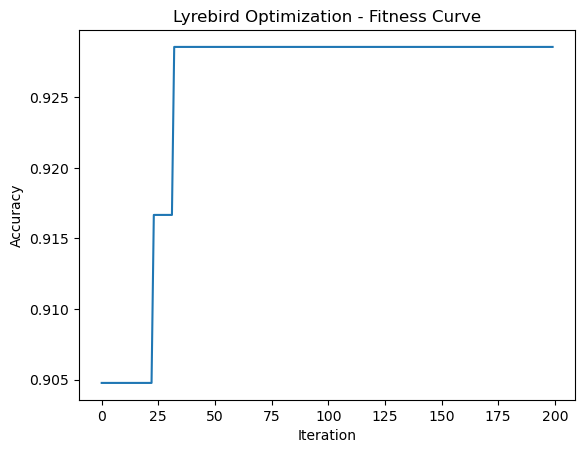

Selected features: [ 1  2  6  7  9 11 13 17 19]


In [21]:
# 1️⃣ SVM with Feature Selection (LOA)

selected_features = LOA_feature_selection(X_train, y_train)
X_train_fs = X_train[:, selected_features]
X_test_fs = X_test[:, selected_features]

svm_fs = SVC(kernel='rbf', probability=True)
svm_fs.fit(X_train_fs, y_train)
y_pred_fs = svm_fs.predict(X_test_fs)
y_prob_fs = svm_fs.predict_proba(X_test_fs)[:, 1]


In [22]:
print("\n--- SVM WITH FEATURE SELECTION ---")
print(classification_report(y_test, y_pred_fs))
print("Accuracy:", accuracy_score(y_test, y_pred_fs))
print("AUC:", roc_auc_score(y_test, y_prob_fs))


--- SVM WITH FEATURE SELECTION ---
              precision    recall  f1-score   support

          no       0.85      0.96      0.90        80
         yes       0.79      0.44      0.56        25

    accuracy                           0.84       105
   macro avg       0.82      0.70      0.73       105
weighted avg       0.83      0.84      0.82       105

Accuracy: 0.8380952380952381
AUC: 0.7270000000000001


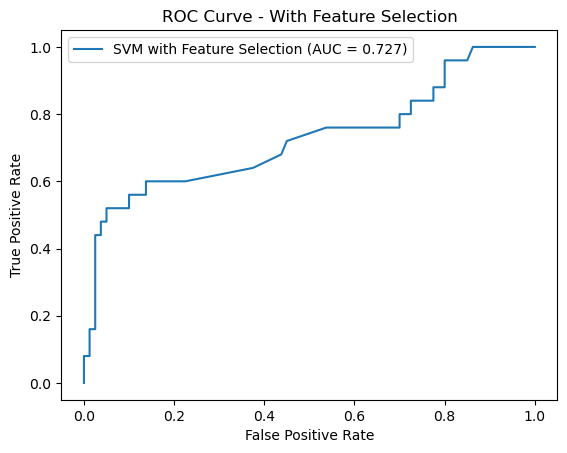

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob_fs, pos_label='yes')
plt.plot(fpr, tpr, label='SVM with Feature Selection (AUC = %.3f)' % roc_auc_score(y_test, y_prob_fs))
plt.title("ROC Curve - With Feature Selection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


--- SVM WITHOUT FEATURE SELECTION ---
              precision    recall  f1-score   support

          no       0.85      0.97      0.91        80
         yes       0.85      0.44      0.58        25

    accuracy                           0.85       105
   macro avg       0.85      0.71      0.74       105
weighted avg       0.85      0.85      0.83       105

Accuracy: 0.8476190476190476
AUC: 0.7062499999999999


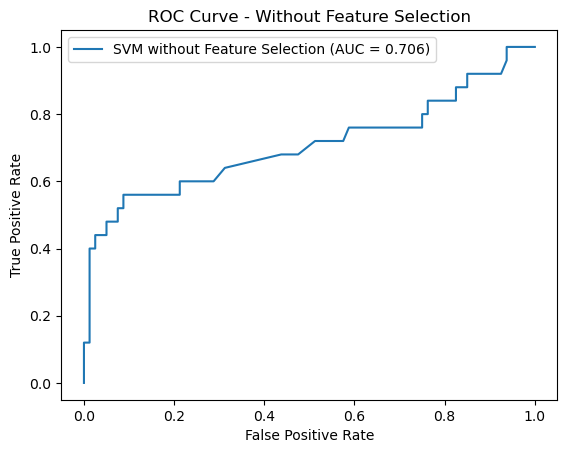

In [24]:
# 2️⃣ SVM without Feature Selection

svm_nofs = SVC(kernel='rbf', probability=True)
svm_nofs.fit(X_train, y_train)
y_pred_nofs = svm_nofs.predict(X_test)
y_prob_nofs = svm_nofs.predict_proba(X_test)[:, 1]

print("\n--- SVM WITHOUT FEATURE SELECTION ---")
print(classification_report(y_test, y_pred_nofs))
print("Accuracy:", accuracy_score(y_test, y_pred_nofs))
print("AUC:", roc_auc_score(y_test, y_prob_nofs))

fpr, tpr, _ = roc_curve(y_test, y_prob_nofs, pos_label='yes')
plt.plot(fpr, tpr, label='SVM without Feature Selection (AUC = %.3f)' % roc_auc_score(y_test, y_prob_nofs))
plt.title("ROC Curve - Without Feature Selection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()